# Premikanje robota v notranjih koordinatah

1. Seznanite se z robotom. Napotke najdete v beležki *Prvi koraki.ipynb*. Pojdite skozi posamezne celice do konca.

2. Premikajte robota po sklepih relativno in absolutno.

3. Premikajte robota v kartezičnih koordinatah relativno in absolutno.

4. Naredite robota podajnega in zajemite trajektorijo v prostoru sklepov na 100 Hz.

5. Naredite robota ponovno togega - na varen način.

6. Izvedite posneto trajektorijo v prostoru sklepov na pribl. 100 Hz. Uporabite metodo `robot.GoTo_q` v zanki. **Bodite pozorni, da skoki v referenčnih vrednostih niso preveliki!**

7. Izriši zajeto in ponovno izvedeno trajektorijo.


**1. Seznanite se z robotom. Napotke najdete v beležki *Prvi koraki.ipynb*. Pojdite skozi posamezne celice do konca.**

**2. Premikajte robota po sklepih relativno in absolutno.**

In [4]:
import rospy
ns = "pingvin_1"
rospy.init_node(ns)
from robotblockset.ros.franka import panda_ros
r = panda_ros(ns=ns, control_strategy="JointImpedance", init_node=False)


Panda::Initialized
shutdown request: [/pingvin_1] Reason: new node registered with same name


In [9]:
r.q

array([-0.0528, -0.1848,  0.0472, -1.8356,  0.0074,  1.6489,  0.7769])

In [2]:
r.JMoveFor([-0.2,0,0,0,0,0,0],3)

0

In [10]:
r.JMove([-0.0528, -0.1848,  0.0472, -1.8356,  0.0074,  1.6489,  0.4769],5)

0

In [11]:
r.JMove(r.q_home,5)

0

**3. Premikajte robota v kartezičnih koordinatah relativno in absolutno.**

In [8]:
r.p

array([ 0.5002, -0.0003,  0.4998])

In [5]:
r.CMoveFor([0,0,0.1], 3)

0

In [7]:
from robotblockset.transformations import rot_x, rp2t, q2r
import numpy as np
p0 = [0.5, 0, 0.5]
R0 = q2r(rot_x(np.pi))
T0 = rp2t(R0,p0)
r.CMove(T0, 5)

0

**4. Naredite robota podajnega in zajemite trajektorijo v prostoru sklepov na 100 Hz.**

In [14]:
import time
import numpy as np
def record_robot_state(robot, frequency, duration):
    interval = 1.0 / frequency
    
    N=int(frequency*duration)
    tt = np.zeros((N,1))
    qt = np.zeros((N,r.nj))
    dqt = np.zeros((N,r.nj))

    i = 0
    start_time = time.monotonic()
    end_time = start_time + duration
    
    last_update = time.monotonic()

    while time.monotonic() <= end_time+interval and i < N:
        t = time.monotonic()
        if t - last_update >= interval:
            
            # Get robot state
            state = robot.GetState()
            
            tt[i] = t-start_time
            qt[i] = r.q
            dqt[i] = r.qdot

            # Update the last recorded time
            last_update = t
            i += 1
        
    return tt, qt, dqt, i, N    



In [15]:
r.SetJointCompliant() 

:Joint compliance changed 
Stiff:[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]
Damp:[ 0.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000]


In [18]:
from utils import pip

time.sleep(1)
pip();
# vzorčimo 3 sekunde pri 100Hz
tt, qt, dqt, i, N = record_robot_state(r,100,3)
pip();

**5. Naredite robota ponovno togega - na varen način.**

In [21]:
import utils
from utils import SoftSetJointCompliance
r.ResetCurrentTarget()
SoftSetJointCompliance(r,r._franka_default.JointCompliance.K,4)

:Joint compliance changed 
Stiff:[ 1200.0000  1200.0000  1200.0000  1200.0000  0.0000  0.0000  0.0000]
Damp:[25 25 25 25 10 10 10]


**6. Izvedite posneto trajektorijo v prostoru sklepov na pribl. 100 Hz. Uporabite metodo `robot.GoTo_q` v zanki. **Bodite pozorni, da skoki v referenčnih vrednostih niso preveliki!****


In [22]:
# Move slowly to the first configuration
r.JMove(qt[0],5)
pip();
N=np.size(qt,0)
for q, qdot, tm in zip(qt, dqt, np.diff(tt, axis=0)): 
    # Call the GoTo_q function
    r.GoTo_q(q,qdot,np.zeros(7),0)
    # time.sleep(1/100.)
    time.sleep(tm[0])

**7. Izriši zajeto in ponovno izvedeno trajektorijo.**


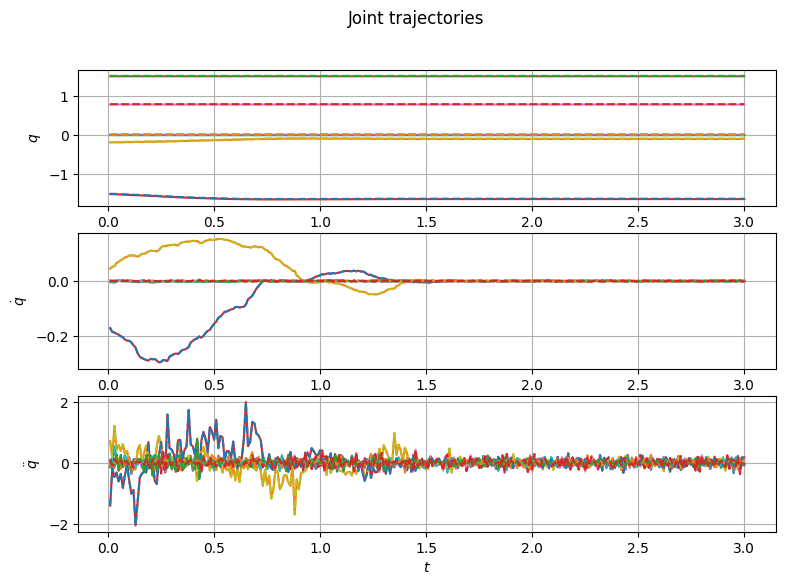

In [23]:
from robotblockset.graphics import plotjtraj
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(9, 6))
fig.suptitle('Joint trajectories')
plotjtraj(tt, qt, dqt, ax=ax);
plotjtraj(tt, qt+0.01, dqt, ax=ax, linestyle="--");